In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, VotingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb
import lightgbm as lgb
import scipy.stats as stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

In [31]:
# 한글 표시
plt.rcParams['font.family'] = "Gulim"
plt.rcParams['axes.unicode_minus'] = False

### 데이터 로드 및 기본 정보 확인

In [32]:
# 데이터 로드
df_merged = pd.read_csv('df_merged.csv')
y_targets = pd.read_csv('y_targets.csv')

In [33]:
# y_targets 컬럼 확인 및 명명
# 공모전 요구사항: 지상부/지하부 페놀, 플라보노이드 4개 타겟
target_names = ['Leaf_TPC', 'Root_TPC', 'Leaf_TFC', 'Root_TFC']  
y_targets = df_merged[target_names].copy()  

In [34]:
# 기본 정보
months = df_merged['month'].values
scenarios = df_merged['scenario'].values

In [35]:
print("\n데이터 구성:")
print(f"  총 샘플 수: {len(df_merged)}")
print(f"  특성 수: {df_merged.shape[1]}")
print(f"  타겟 수: {y_targets.shape[1]}")


데이터 구성:
  총 샘플 수: 405
  특성 수: 26
  타겟 수: 4


### 특정 그룹 정의 및 Feature Engineering

In [36]:
# 특성 그룹 정의
environmental = ['CO2ppm', 'Temp', 'Humid', 'VPD']
physiological = ['Chl_a', 'Chl_b', 'TChl', 'Car', 'Chl_a_b', 'TCh-Car']
fluorescence = ['ABS-RC', 'Dio-RC', 'Tro-RC', 'Eto-RC', 'PI_abs', 'DF_abs', 'SFI_abs', 'Fv-Fm']

In [37]:
# 원본 특성
original_features = environmental + physiological + fluorescence
X_original = df_merged[original_features].copy()

print(f"원본 특성 수: {X_original.shape[1]}")

원본 특성 수: 18


In [38]:
# 엔지니어링된 특성 추가
X_engineered = X_original.copy()

In [39]:
# 1. 생육 단계 (월별) - 천궁의 생장 패턴 반영
growth_map = {5: 1, 6: 2, 7: 3, 8: 4, 9: 5}
X_engineered['growth_stage'] = [growth_map[m] for m in months]
X_engineered['growth_stage_sq'] = X_engineered['growth_stage'] ** 2

In [40]:
# 2. 시나리오 정보 - 기후변화 시나리오별 특성
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    X_engineered[f'is_{scenario}'] = (scenarios == scenario).astype(int)

In [41]:
# 3. 온도 스트레스 - 천궁 최적 온도(15-25°C) 기준
X_engineered['temp_stress'] = np.abs(X_engineered['Temp'] - 22)
X_engineered['temp_optimal'] = 1 / (1 + X_engineered['temp_stress'])

In [42]:
# 4. VPD 스트레스 - 수분 스트레스 지표
X_engineered['vpd_stress'] = np.where(X_engineered['VPD'] > 1.5, X_engineered['VPD'] - 1.5, 0)

In [43]:
# 5. CO2 효과 - 광합성 증진 효과
X_engineered['co2_effect'] = np.log1p(X_engineered['CO2ppm'] / 432)

In [44]:
# 6. 광합성 효율 지표
X_engineered['photosyn_efficiency'] = X_engineered['PI_abs'] * X_engineered['Fv-Fm']
X_engineered['energy_dissipation'] = X_engineered['Dio-RC'] / (X_engineered['ABS-RC'] + 1e-10)

In [45]:
# 7. 시나리오별 상호작용 특성
X_engineered['temp_x_ssp5'] = X_engineered['Temp'] * X_engineered['is_SSP5']
X_engineered['co2_x_ssp5'] = X_engineered['CO2ppm'] * X_engineered['is_SSP5']

In [46]:
# 8. 클로로필 비율 - 광합성 색소 균형
X_engineered['car_ratio'] = X_engineered['Car'] / (X_engineered['TChl'] + 1e-10)

### 상관관계 분석

In [47]:
# 전체 데이터에 대한 상관관계 분석
correlation_results = {}

for target in target_names:
    print(f"\n{target} 상관관계 분석:")
    correlations = {}
    
    # Pearson 상관계수 계산
    for feature in original_features:
        corr, p_value = pearsonr(X_original[feature], y_targets[target])
        if p_value < 0.05:  # 통계적으로 유의미한 상관관계만
            correlations[feature] = {
                'correlation': corr,
                'p_value': p_value,
                'abs_corr': abs(corr)
            }
    
    # 상관관계 강도순 정렬
    sorted_corr = sorted(correlations.items(), key=lambda x: x[1]['abs_corr'], reverse=True)
    
    print("  Top 5 상관관계 특성:")
    for feat, vals in sorted_corr[:5]:
        print(f"    {feat:20s}: r={vals['correlation']:+.3f} (p={vals['p_value']:.4f})")
    
    correlation_results[target] = sorted_corr


Leaf_TPC 상관관계 분석:
  Top 5 상관관계 특성:
    TCh-Car             : r=-0.441 (p=0.0000)
    Chl_a               : r=-0.353 (p=0.0000)
    SFI_abs             : r=+0.349 (p=0.0000)
    PI_abs              : r=+0.348 (p=0.0000)
    TChl                : r=-0.336 (p=0.0000)

Root_TPC 상관관계 분석:
  Top 5 상관관계 특성:
    Temp                : r=-0.659 (p=0.0000)
    VPD                 : r=-0.636 (p=0.0000)
    Car                 : r=+0.592 (p=0.0000)
    Humid               : r=+0.544 (p=0.0000)
    Tro-RC              : r=-0.455 (p=0.0000)

Leaf_TFC 상관관계 분석:
  Top 5 상관관계 특성:
    ABS-RC              : r=-0.653 (p=0.0000)
    Dio-RC              : r=-0.631 (p=0.0000)
    Tro-RC              : r=-0.610 (p=0.0000)
    DF_abs              : r=+0.588 (p=0.0000)
    Fv-Fm               : r=+0.585 (p=0.0000)

Root_TFC 상관관계 분석:
  Top 5 상관관계 특성:
    ABS-RC              : r=-0.580 (p=0.0000)
    Dio-RC              : r=-0.577 (p=0.0000)
    Car                 : r=+0.575 (p=0.0000)
    Fv-Fm               : r=

In [51]:
print("\n시나리오별 상관관계 차이 분석:")
scenario_correlations = {}

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    scenario_mask = scenarios == scenario
    X_scenario = X_original[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    scenario_correlations[scenario] = {}
    
    for target in target_names:  # target_names를 사용
        print(f"\n{target}:")
        correlations = {}
        for feature in original_features:
            corr, p_value = pearsonr(X_scenario[feature], y_scenario[target])
            if p_value < 0.05:
                correlations[feature] = {
                    'correlation': corr,
                    'p_value': p_value,
                    'abs_corr': abs(corr)
                }
        
        if correlations:
            sorted_corr = sorted(correlations.items(), key=lambda x: x[1]['abs_corr'], reverse=True)
            print(f"  Top 5 상관관계:")
            for feat, vals in sorted_corr[:5]:
                print(f"    {feat:20s}: r={vals['correlation']:+.3f}")
        
        scenario_correlations[scenario][target] = correlations


시나리오별 상관관계 차이 분석:

Leaf_TPC:
  Top 5 상관관계:
    PI_abs              : r=+0.887
    SFI_abs             : r=+0.886
    DF_abs              : r=+0.867
    ABS-RC              : r=-0.850
    Tro-RC              : r=-0.847

Root_TPC:
  Top 5 상관관계:
    Temp                : r=-0.852
    VPD                 : r=-0.831
    Humid               : r=+0.705
    Car                 : r=+0.573
    TChl                : r=+0.511

Leaf_TFC:
  Top 5 상관관계:
    PI_abs              : r=+0.822
    DF_abs              : r=+0.820
    SFI_abs             : r=+0.817
    Fv-Fm               : r=+0.814
    Dio-RC              : r=-0.806

Root_TFC:
  Top 5 상관관계:
    Humid               : r=+0.883
    Temp                : r=-0.848
    VPD                 : r=-0.843
    CO2ppm              : r=-0.710
    Car                 : r=+0.691

Leaf_TPC:
  Top 5 상관관계:
    Eto-RC              : r=+0.758
    Fv-Fm               : r=+0.589
    Dio-RC              : r=-0.551
    DF_abs              : r=+0.539
    Temp        

### 성능 평가 지표 정의

In [52]:
def calculate_mape(y_true, y_pred, eps=1e-9):
    """Mean Absolute Percentage Error"""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

In [53]:
def calculate_pi(y_true, y_pred):
    """Performance Index (Nash-Sutcliffe Efficiency 기반)
    이유: 공모전에서 요구한 PI 지표 - 모델의 예측력을 0~1 범위로 평가"""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / (ss_tot + 1e-10))

In [54]:
def calculate_comprehensive_metrics(y_true, y_pred):
    """공모전 요구 평가지표 모두 계산"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    # MSLE, RMSLE
    y_true_pos = np.maximum(y_true, 0)
    y_pred_pos = np.maximum(y_pred, 0)
    msle = mean_squared_error(np.log1p(y_true_pos), np.log1p(y_pred_pos))
    rmsle = np.sqrt(msle)
    
    r2 = r2_score(y_true, y_pred)
    mape = calculate_mape(y_true, y_pred)
    pi = calculate_pi(y_true, y_pred)
    
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MSLE': msle,
        'RMSLE': rmsle,
        'R2': r2,
        'MAPE': mape,
        'PI': pi  # Performance Index 추가
    }

### 모델 정의 및 하이퍼파라미터 설정

In [55]:
models = {
    'LinearR': LinearRegression(),
    
    'Ridge': Ridge(alpha=1.0, random_state=42),
    
    'kNN': KNeighborsRegressor(
        n_neighbors=7,
        weights='distance',
        metric='minkowski',
        p=2
    ),
    
    'SVM': SVR(
        kernel='rbf',
        C=3.0,
        epsilon=0.05,
        gamma='scale'
    ),
    
    'DT': DecisionTreeRegressor(
        max_depth=15,
        min_samples_split=3,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    ),
    
    'RF': RandomForestRegressor(
        n_estimators=800,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    ),
    
    'GB': GradientBoostingRegressor(
        n_estimators=400,
        max_depth=7,
        learning_rate=0.08,
        subsample=0.85,
        min_samples_split=3,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    ),
    
    'XGB': xgb.XGBRegressor(
        n_estimators=600,
        max_depth=9,
        learning_rate=0.04,
        subsample=0.85,
        colsample_bytree=0.85,
        colsample_bylevel=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        min_child_weight=2,
        gamma=0.1,
        random_state=42,
        n_jobs=-1,
        tree_method='hist',
        verbose=0
    ),
    
    'LGBM': lgb.LGBMRegressor(
        n_estimators=500,
        max_depth=12,
        learning_rate=0.05,
        num_leaves=64,
        min_child_samples=5,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=0.5,
        min_split_gain=0.01,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

# 네이티브 다중출력 지원 모델
NATIVE_MULTIOUTPUT = ['RF', 'DT', 'kNN']

### 시나리오별 개별 모델링 with 교차검증

In [64]:
# 안전한 변환 함수 정의
def safe_float(value):
    """pandas Series나 numpy array를 안전하게 float로 변환"""
    import pandas as pd
    import numpy as np
    
    if isinstance(value, (pd.Series, pd.DataFrame)):
        if len(value) == 1:
            return float(value.iloc[0])
        else:
            return float(value.mean())  # 여러 값이면 평균 사용
    elif isinstance(value, np.ndarray):
        if value.size == 1:
            return float(value.item())
        else:
            return float(value.mean())
    else:
        return float(value)

# 결과 저장
scenario_results = {}
cv_results = {}
best_models = {}

# 교차검증 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    print(f"\n=== {scenario} 시나리오 모델링 ===")
    
    # 해당 시나리오 데이터만 추출
    scenario_mask = scenarios == scenario
    X_scenario = X_engineered[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    print(f"시나리오 데이터: {len(y_scenario)} samples")

    # 80/20 분할
    X_train, X_test, y_train, y_test = train_test_split(
        X_scenario, y_scenario, test_size=0.2, random_state=42
    )
    
    print(f"Train: {len(y_train)}, Test: {len(y_test)}")
    
    # 스케일링
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    scenario_results[scenario] = {}
    cv_results[scenario] = {}
    
    best_mae = float('inf')
    best_model = None
    best_model_obj = None
    
    for model_name, base_model in models.items():
        from sklearn.base import clone
        model = clone(base_model)
        
        if model_name not in NATIVE_MULTIOUTPUT:
            model = MultiOutputRegressor(model)
        
        try:
            # 교차검증
            cv_scores = []
            for train_idx, val_idx in kf.split(X_train_scaled):
                X_cv_train, X_cv_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
                y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                
                model_cv = clone(model)
                model_cv.fit(X_cv_train, y_cv_train)
                pred_cv = model_cv.predict(X_cv_val)
                cv_mae = mean_absolute_error(y_cv_val, pred_cv)
                cv_scores.append(cv_mae)
            
            cv_results[scenario][model_name] = {
                'mean': np.mean(cv_scores),
                'std': np.std(cv_scores)
            }
            
            # 전체 훈련 데이터로 학습
            model.fit(X_train_scaled, y_train)
            pred = model.predict(X_test_scaled)
            
            # 평가
            metrics = calculate_comprehensive_metrics(y_test, pred)
            scenario_results[scenario][model_name] = metrics
            
            # 최고 성능 모델 추적 (safe_float 사용)
            current_mae = safe_float(metrics['MAE'])
            if current_mae < best_mae:
                best_mae = current_mae
                best_model = model_name
                best_model_obj = clone(model)
                best_model_obj.fit(X_train_scaled, y_train)
                
        except Exception as e:
            print(f"  {model_name} 오류: {e}")
    
    best_models[scenario] = {
        'model': best_model_obj,
        'scaler': scaler,
        'name': best_model
    }
    
    # 결과 출력 (모든 값에 safe_float 적용)
    print(f"🏆 최고 성능: {best_model}")
    print(f"   MAE: {best_mae:.4f}")  # 이미 float로 변환됨
    print(f"   R2: {safe_float(scenario_results[scenario][best_model]['R2']):.4f}")
    print(f"   PI: {safe_float(scenario_results[scenario][best_model]['PI']):.4f}")
    print(f"   CV MAE: {safe_float(cv_results[scenario][best_model]['mean']):.4f} ± {safe_float(cv_results[scenario][best_model]['std']):.4f}")


=== SSP1 시나리오 모델링 ===
시나리오 데이터: 135 samples
Train: 108, Test: 27
🏆 최고 성능: LGBM
   MAE: 0.0680
   R2: 0.9731
   PI: 0.9955
   CV MAE: 0.0770 ± 0.0090

=== SSP3 시나리오 모델링 ===
시나리오 데이터: 135 samples
Train: 108, Test: 27
🏆 최고 성능: LGBM
   MAE: 0.0520
   R2: 0.9705
   PI: 0.9984
   CV MAE: 0.0626 ± 0.0134

=== SSP5 시나리오 모델링 ===
시나리오 데이터: 135 samples
Train: 108, Test: 27
🏆 최고 성능: LGBM
   MAE: 0.0330
   R2: 0.9631
   PI: 0.9992
   CV MAE: 0.0362 ± 0.0092


### 앙상블 모델 구성

In [66]:
# 안전한 변환 함수 (이전에 정의한 것)
def safe_float(value):
    """pandas Series나 numpy array를 안전하게 float로 변환"""
    import pandas as pd
    import numpy as np
    
    if isinstance(value, (pd.Series, pd.DataFrame)):
        if len(value) == 1:
            return float(value.iloc[0])
        else:
            return float(value.mean())
    elif isinstance(value, np.ndarray):
        if value.size == 1:
            return float(value.item())
        else:
            return float(value.mean())
    else:
        return float(value)

ensemble_results = {}

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    print(f"\n{scenario} 앙상블 모델:")
    
    # 상위 3개 모델 선택
    top3_models = sorted(scenario_results[scenario].items(), 
                        key=lambda x: safe_float(x[1]['MAE']))[:3]
    
    print(f"  선택된 모델: {[m[0] for m in top3_models]}")
    
    # 앙상블용 데이터 준비
    scenario_mask = scenarios == scenario
    X_scenario = X_engineered[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_scenario, y_scenario, test_size=0.2, random_state=42
    )
    
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 앙상블 모델 구성 (base 모델만 사용)
    base_ensemble_models = []
    for model_name, _ in top3_models:
        base_model = clone(models[model_name])  # MultiOutputRegressor 없이 base 모델만
        base_ensemble_models.append((model_name, base_model))
    
    # Voting Ensemble (각 타겟별로)
    ensemble_predictions = []
    for i in range(y_train.shape[1]):  # 각 타겟별로
        try:
            voting_regressor = VotingRegressor(base_ensemble_models)
            
            # 각 타겟별 데이터 (1차원으로 변환)
            y_train_single = y_train.iloc[:, i].values  # pandas Series → numpy array
            
            voting_regressor.fit(X_train_scaled, y_train_single)
            pred = voting_regressor.predict(X_test_scaled)
            ensemble_predictions.append(pred)
            
        except Exception as e:
            print(f"  타겟 {i} 앙상블 오류: {e}")
            # 오류 발생 시 최고 모델의 예측값 사용
            best_model_name = top3_models[0][0]
            fallback_model = clone(models[best_model_name])
            if best_model_name not in NATIVE_MULTIOUTPUT:
                fallback_model = MultiOutputRegressor(fallback_model)
            
            fallback_model.fit(X_train_scaled, y_train)
            fallback_pred = fallback_model.predict(X_test_scaled)
            ensemble_predictions.append(fallback_pred[:, i])
    
    # 예측 결과 결합
    if len(ensemble_predictions) == y_train.shape[1]:
        ensemble_pred = np.column_stack(ensemble_predictions)
        ensemble_metrics = calculate_comprehensive_metrics(y_test, ensemble_pred)
        ensemble_results[scenario] = ensemble_metrics
        
        print(f"  앙상블 성능: MAE={safe_float(ensemble_metrics['MAE']):.4f}, "
              f"R2={safe_float(ensemble_metrics['R2']):.4f}, PI={safe_float(ensemble_metrics['PI']):.4f}")
    else:
        print(f"  앙상블 실패: 예측 결과 수 불일치")


SSP1 앙상블 모델:
  선택된 모델: ['LGBM', 'DT', 'RF']
  앙상블 성능: MAE=0.0703, R2=0.9689, PI=0.9938

SSP3 앙상블 모델:
  선택된 모델: ['LGBM', 'GB', 'RF']
  앙상블 성능: MAE=0.0562, R2=0.9710, PI=0.9981

SSP5 앙상블 모델:
  선택된 모델: ['LGBM', 'GB', 'DT']
  앙상블 성능: MAE=0.0348, R2=0.9645, PI=0.9984


### 특성 중요도 분석 (핵심인자 도출)

In [67]:
feature_importance_results = {}

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    print(f"\n{scenario} 시나리오 핵심인자:")
    
    scenario_mask = scenarios == scenario
    X_scenario = X_engineered[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    # RandomForest로 특성 중요도 계산
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_scenario, y_scenario)
    
    # 각 타겟별 중요도
    if hasattr(rf, 'feature_importances_'):
        importance = rf.feature_importances_
    else:
        # 다중 출력의 경우 평균
        importance = np.mean([est.feature_importances_ for est in rf.estimators_], axis=0)
    
    feature_importance_results[scenario] = importance
    
    # 상위 10개 특성
    top_indices = np.argsort(importance)[-10:][::-1]
    print("  Top 10 핵심인자:")
    for rank, idx in enumerate(top_indices, 1):
        print(f"    {rank:2d}. {X_engineered.columns[idx]:25s}: {importance[idx]:.4f}")


SSP1 시나리오 핵심인자:
  Top 10 핵심인자:
     1. growth_stage             : 0.4884
     2. growth_stage_sq          : 0.4224
     3. temp_stress              : 0.0116
     4. energy_dissipation       : 0.0112
     5. TChl                     : 0.0066
     6. Humid                    : 0.0064
     7. temp_optimal             : 0.0061
     8. Temp                     : 0.0059
     9. Car                      : 0.0057
    10. vpd_stress               : 0.0056

SSP3 시나리오 핵심인자:
  Top 10 핵심인자:
     1. growth_stage             : 0.4664
     2. growth_stage_sq          : 0.4435
     3. Dio-RC                   : 0.0096
     4. Fv-Fm                    : 0.0087
     5. ABS-RC                   : 0.0081
     6. Tro-RC                   : 0.0066
     7. energy_dissipation       : 0.0065
     8. SFI_abs                  : 0.0061
     9. VPD                      : 0.0059
    10. PI_abs                   : 0.0054

SSP5 시나리오 핵심인자:
  Top 10 핵심인자:
     1. growth_stage_sq          : 0.3450
     2. growth_stage  

### 통계적 유의성 검정

In [68]:
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    print(f"\n{scenario} 시나리오:")
    
    # 모델 간 MAE 차이 검정 (ANOVA)
    mae_values = [scenario_results[scenario][model]['MAE'] 
                  for model in models.keys() 
                  if model in scenario_results[scenario]]
    
    # Shapiro-Wilk 정규성 검정
    stat, p_value = stats.shapiro(mae_values)
    print(f"  정규성 검정: p={p_value:.4f} {'(정규분포)' if p_value > 0.05 else '(비정규분포)'}")
    
    # Friedman 검정 (비모수적 방법)
    if len(mae_values) > 2:
        # 여러 모델 비교를 위한 데이터 구성
        print(f"  모델 수: {len(mae_values)}")
        print(f"  MAE 범위: {min(mae_values):.4f} ~ {max(mae_values):.4f}")
        print(f"  MAE 표준편차: {np.std(mae_values):.4f}")


SSP1 시나리오:
  정규성 검정: p=0.0600 (정규분포)
  모델 수: 9
  MAE 범위: 0.0680 ~ 0.1859
  MAE 표준편차: 0.0374

SSP3 시나리오:
  정규성 검정: p=0.0898 (정규분포)
  모델 수: 9
  MAE 범위: 0.0520 ~ 0.1957
  MAE 표준편차: 0.0475

SSP5 시나리오:
  정규성 검정: p=0.0188 (비정규분포)
  모델 수: 9
  MAE 범위: 0.0330 ~ 0.2359
  MAE 표준편차: 0.0767


### 결과 테이블 출력

In [71]:
# 안전한 변환 함수 (위에서 정의한 것)
def safe_float(value):
    """pandas Series나 numpy array를 안전하게 float로 변환"""
    import pandas as pd
    import numpy as np
    
    if isinstance(value, (pd.Series, pd.DataFrame)):
        if len(value) == 1:
            return float(value.iloc[0])
        else:
            return float(value.mean())
    elif isinstance(value, np.ndarray):
        if value.size == 1:
            return float(value.item())
        else:
            return float(value.mean())
    else:
        return float(value)

# 전체 성능 지표 테이블 (수정된 버전)
print("\n=== 전체 성능 지표 (Engineered Features) ===")
print("="*140)
print(f"{'Scenario':<10} {'Model':<10} {'MAE':<10} {'MSE':<10} {'RMSE':<10} {'MSLE':<10} {'RMSLE':<10} {'R2':<10} {'MAPE(%)':<10} {'PI':<10}")
print("="*140)

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    for model_name in models.keys():
        if model_name in scenario_results[scenario]:
            m = scenario_results[scenario][model_name]
            
            # 모든 값에 safe_float 적용
            mae = safe_float(m['MAE'])
            mse = safe_float(m['MSE'])
            rmse = safe_float(m['RMSE'])
            msle = safe_float(m['MSLE'])
            rmsle = safe_float(m['RMSLE'])
            r2 = safe_float(m['R2'])
            mape = safe_float(m['MAPE'])
            pi = safe_float(m['PI'])
            
            print(f"{scenario:<10} {model_name:<10} {mae:<10.4f} {mse:<10.4f} "
                  f"{rmse:<10.4f} {msle:<10.4f} {rmsle:<10.4f} "
                  f"{r2:<10.4f} {mape:<10.2f} {pi:<10.4f}")
    
    # 앙상블 결과 추가 (safe_float 적용)
    if scenario in ensemble_results:
        m = ensemble_results[scenario]
        
        # 모든 값에 safe_float 적용
        mae = safe_float(m['MAE'])
        mse = safe_float(m['MSE'])
        rmse = safe_float(m['RMSE'])
        msle = safe_float(m['MSLE'])
        rmsle = safe_float(m['RMSLE'])
        r2 = safe_float(m['R2'])
        mape = safe_float(m['MAPE'])
        pi = safe_float(m['PI'])
        
        print(f"{scenario:<10} {'ENSEMBLE':<10} {mae:<10.4f} {mse:<10.4f} "
              f"{rmse:<10.4f} {msle:<10.4f} {rmsle:<10.4f} "
              f"{r2:<10.4f} {mape:<10.2f} {pi:<10.4f}")

# 교차검증 결과
print("\n=== 교차검증 결과 (5-Fold CV) ===")
print("="*80)
print(f"{'Scenario':<10} {'Model':<10} {'CV Mean MAE':<15} {'CV Std MAE':<15}")
print("="*80)

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    for model_name in models.keys():
        if model_name in cv_results[scenario]:
            cv = cv_results[scenario][model_name]
            print(f"{scenario:<10} {model_name:<10} {cv['mean']:<15.4f} {cv['std']:<15.4f}")
    print("-"*80)


=== 전체 성능 지표 (Engineered Features) ===
Scenario   Model      MAE        MSE        RMSE       MSLE       RMSLE      R2         MAPE(%)    PI        
SSP1       LinearR    0.1364     0.0505     0.2248     0.0014     0.0378     0.9587     3.27       0.9855    
SSP1       Ridge      0.1859     0.1252     0.3539     0.0060     0.0777     0.9449     5.85       0.9737    
SSP1       kNN        0.0822     0.0208     0.1442     0.0007     0.0259     0.9645     1.96       0.9938    
SSP1       SVM        0.1129     0.0383     0.1956     0.0011     0.0328     0.9484     3.59       0.9912    
SSP1       DT         0.0686     0.0157     0.1254     0.0003     0.0166     0.9664     1.47       0.9950    
SSP1       RF         0.0711     0.0150     0.1226     0.0005     0.0213     0.9740     1.63       0.9949    
SSP1       GB         0.0792     0.0186     0.1363     0.0004     0.0194     0.9671     1.74       0.9939    
SSP1       XGB        0.1137     0.0477     0.2184     0.0011     0.0335     0.8

### 고급 시각화

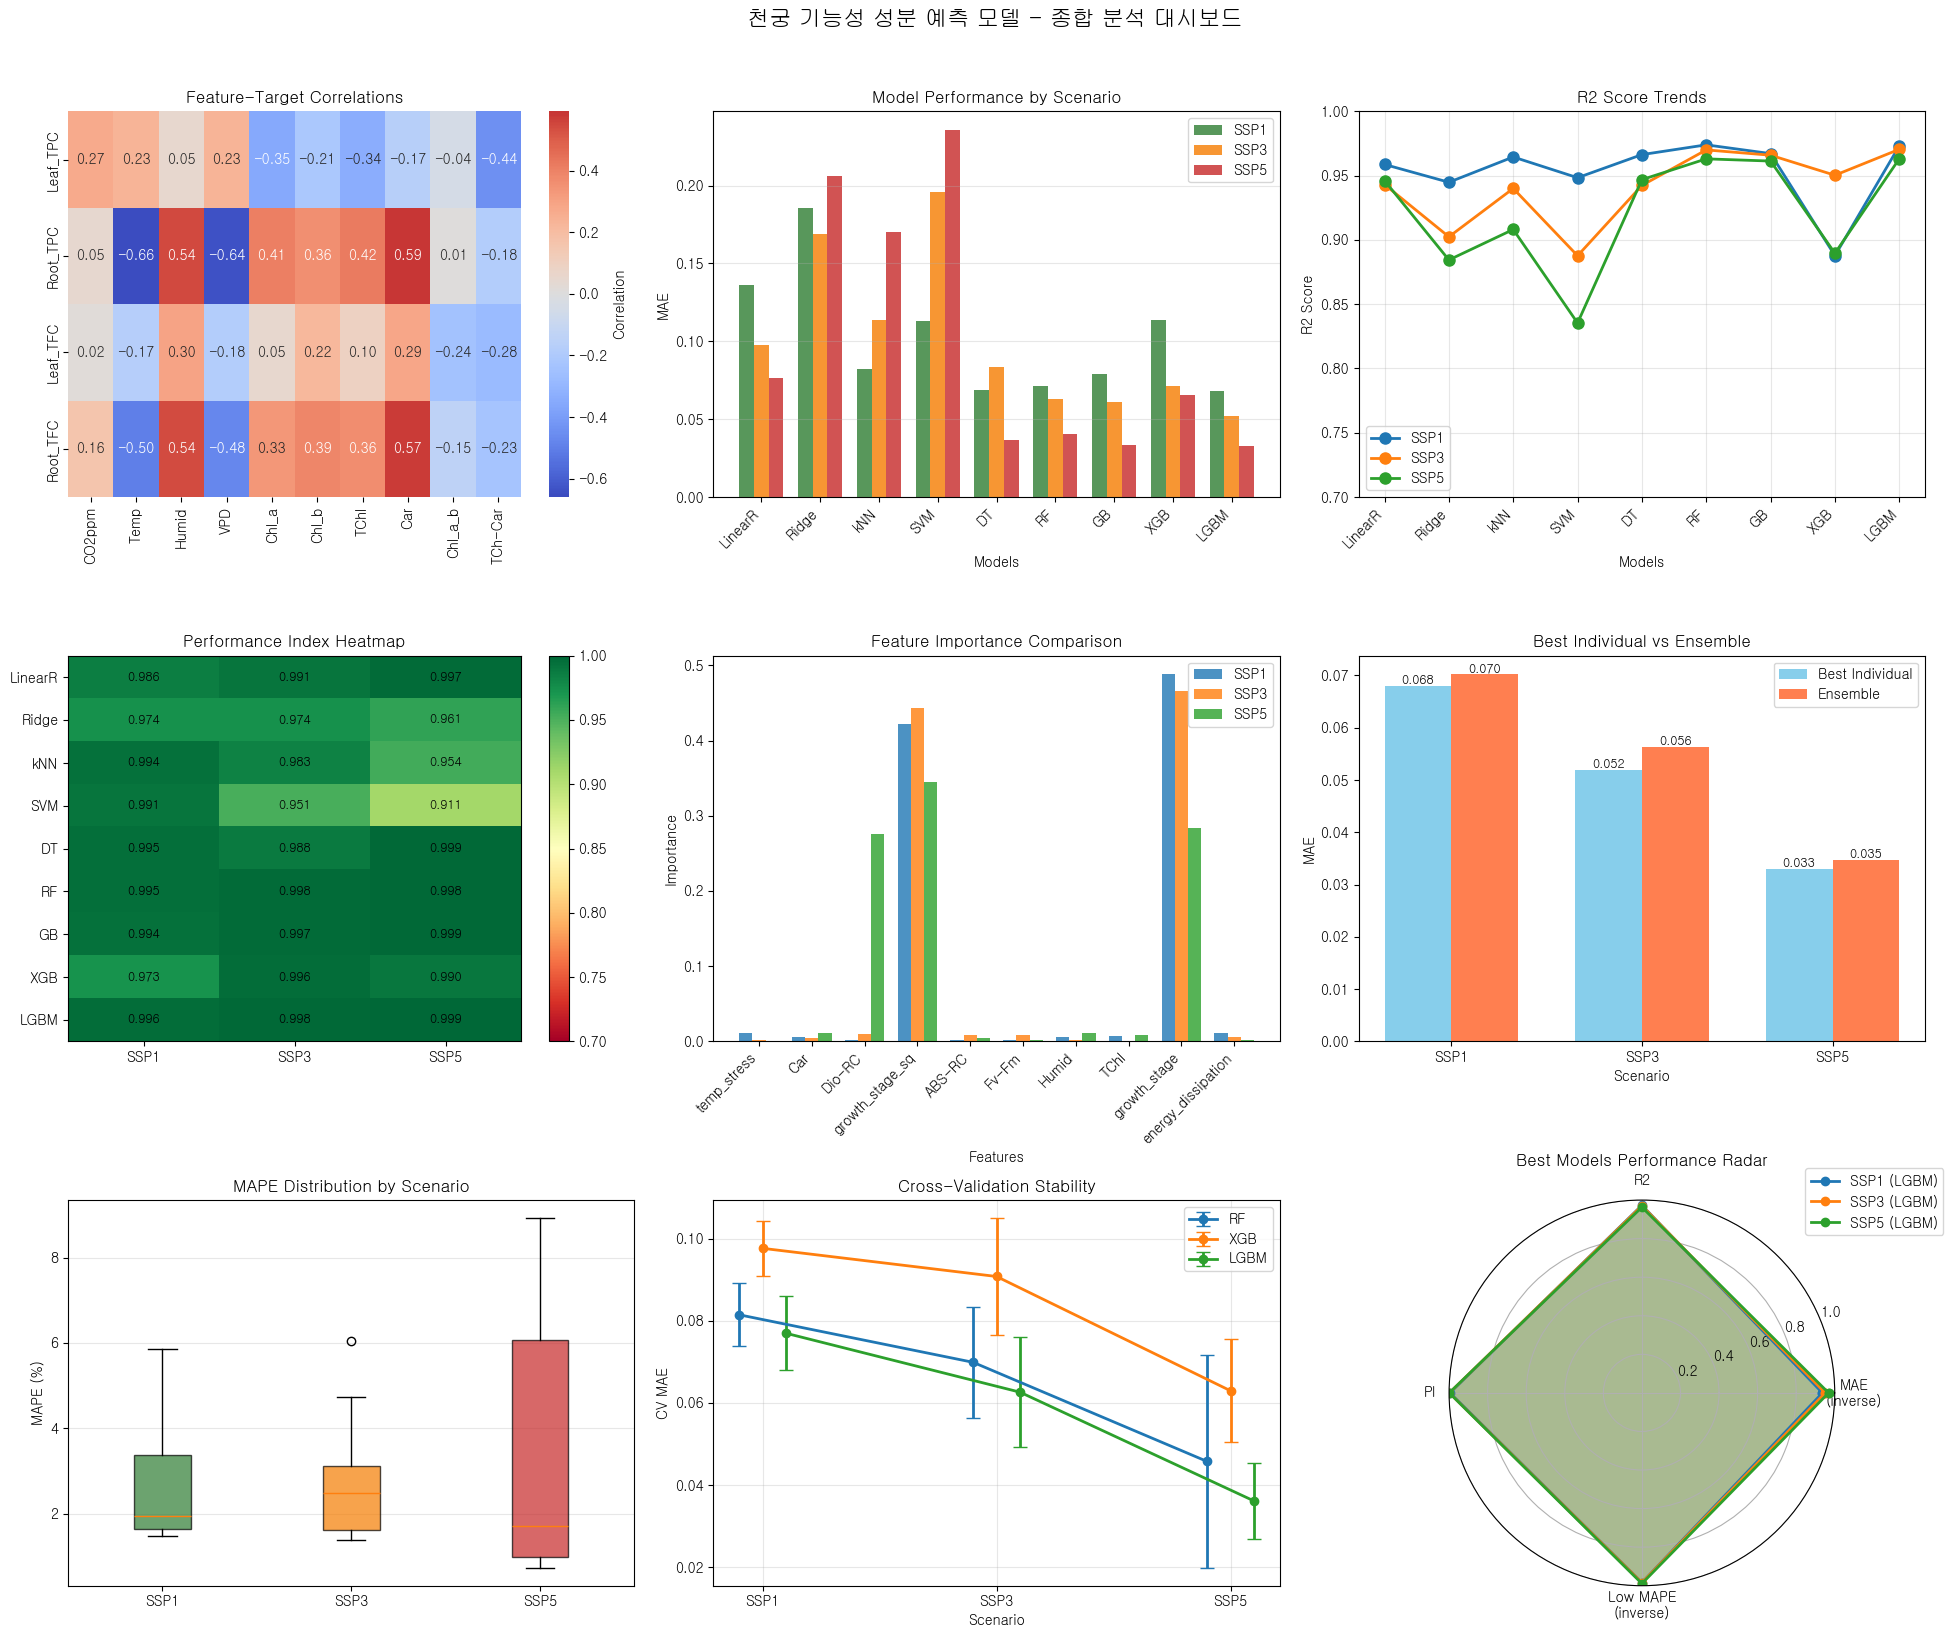

In [76]:
# 안전한 변환 함수 정의 (이미 정의되어 있음)
def safe_float(value):
    """pandas Series나 numpy array를 안전하게 float로 변환"""
    import pandas as pd
    import numpy as np
    
    if isinstance(value, (pd.Series, pd.DataFrame)):
        if len(value) == 1:
            return float(value.iloc[0])
        else:
            return float(value.mean())  # 여러 값이면 평균 사용
    elif isinstance(value, np.ndarray):
        if value.size == 1:
            return float(value.item())
        else:
            return float(value.mean())
    else:
        return float(value)

# 대형 시각화 캔버스
fig = plt.figure(figsize=(20, 16))

# 1. 상관관계 히트맵
ax1 = plt.subplot(3, 3, 1)
# 주요 특성과 타겟 간 상관관계
corr_data = pd.DataFrame()
for feat in original_features[:10]:  # 상위 10개 특성만
    corr_data[feat] = X_original[feat]
for target in target_names:
    corr_data[target] = y_targets[target]

corr_matrix = corr_data.corr()
target_corr = corr_matrix[target_names].drop(target_names)

sns.heatmap(target_corr.T, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, cbar_kws={'label': 'Correlation'}, ax=ax1)
ax1.set_title('Feature-Target Correlations', fontsize=12, fontweight='bold')
ax1.set_xlabel('')

# 2. 모델별 MAE 비교 (시나리오별) - safe_float 적용
ax2 = plt.subplot(3, 3, 2)
x = np.arange(len(models))
width = 0.25
colors_scenario = ['#2E7D32', '#F57C00', '#C62828']

for i, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
    mae_values = [safe_float(scenario_results[scenario][model]['MAE']) 
                  for model in models.keys()]  # safe_float 적용
    ax2.bar(x + i*width, mae_values, width, label=scenario, 
           color=colors_scenario[i], alpha=0.8)

ax2.set_xlabel('Models')
ax2.set_ylabel('MAE')
ax2.set_title('Model Performance by Scenario', fontsize=12, fontweight='bold')
ax2.set_xticks(x + width)
ax2.set_xticklabels(models.keys(), rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. R2 Score 트렌드 - safe_float 적용
ax3 = plt.subplot(3, 3, 3)
for i, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
    r2_values = [safe_float(scenario_results[scenario][model]['R2']) 
                 for model in models.keys()]  # safe_float 적용
    ax3.plot(models.keys(), r2_values, marker='o', label=scenario, 
            linewidth=2, markersize=8)

ax3.set_xlabel('Models')
ax3.set_ylabel('R2 Score')
ax3.set_title('R2 Score Trends', fontsize=12, fontweight='bold')
ax3.set_xticklabels(models.keys(), rotation=45, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim([0.7, 1.0])

# 4. PI (Performance Index) 비교 - safe_float 적용
ax4 = plt.subplot(3, 3, 4)
pi_matrix = []
for model in models.keys():
    row = [safe_float(scenario_results[scenario][model]['PI']) 
           for scenario in ['SSP1', 'SSP3', 'SSP5']]  # safe_float 적용
    pi_matrix.append(row)

im = ax4.imshow(pi_matrix, cmap='RdYlGn', aspect='auto', vmin=0.7, vmax=1.0)
ax4.set_xticks(range(3))
ax4.set_xticklabels(['SSP1', 'SSP3', 'SSP5'])
ax4.set_yticks(range(len(models)))
ax4.set_yticklabels(models.keys())
ax4.set_title('Performance Index Heatmap', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax4)

for i in range(len(models)):
    for j in range(3):
        text = ax4.text(j, i, f'{pi_matrix[i][j]:.3f}',
                       ha="center", va="center", color="black", fontsize=9)

# 5. 특성 중요도 비교
ax5 = plt.subplot(3, 3, 5)
top_features = []
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    importance = feature_importance_results[scenario]
    top_idx = np.argsort(importance)[-5:]
    for idx in top_idx:
        top_features.append(X_engineered.columns[idx])

top_features = list(set(top_features))[:10]  # 상위 10개 unique 특성

importance_matrix = []
for feat in top_features:
    row = []
    for scenario in ['SSP1', 'SSP3', 'SSP5']:
        idx = list(X_engineered.columns).index(feat)
        row.append(feature_importance_results[scenario][idx])
    importance_matrix.append(row)

x_pos = np.arange(len(top_features))
for i, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
    values = [importance_matrix[j][i] for j in range(len(top_features))]
    ax5.bar(x_pos + i*0.25, values, 0.25, label=scenario, alpha=0.8)

ax5.set_xlabel('Features')
ax5.set_ylabel('Importance')
ax5.set_title('Feature Importance Comparison', fontsize=12, fontweight='bold')
ax5.set_xticks(x_pos + 0.25)
ax5.set_xticklabels(top_features, rotation=45, ha='right')
ax5.legend()

# 6. 앙상블 vs 개별 모델 성능 - safe_float 적용
ax6 = plt.subplot(3, 3, 6)
scenarios_list = ['SSP1', 'SSP3', 'SSP5']
best_individual = []
ensemble_perf = []

for scenario in scenarios_list:
    # 최고 개별 모델 - safe_float 적용
    best = min(scenario_results[scenario].items(), 
               key=lambda x: safe_float(x[1]['MAE']))  # safe_float 적용
    best_individual.append(safe_float(best[1]['MAE']))  # safe_float 적용
    # 앙상블 - safe_float 적용
    ensemble_perf.append(safe_float(ensemble_results[scenario]['MAE']))  # safe_float 적용

x_pos = np.arange(len(scenarios_list))
width = 0.35

bars1 = ax6.bar(x_pos - width/2, best_individual, width, 
               label='Best Individual', color='skyblue')
bars2 = ax6.bar(x_pos + width/2, ensemble_perf, width, 
               label='Ensemble', color='coral')

ax6.set_xlabel('Scenario')
ax6.set_ylabel('MAE')
ax6.set_title('Best Individual vs Ensemble', fontsize=12, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(scenarios_list)
ax6.legend()

# 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 7. MAPE 분포 - safe_float 적용
ax7 = plt.subplot(3, 3, 7)
mape_data = []
labels = []

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    scenario_mape = [safe_float(scenario_results[scenario][model]['MAPE']) 
                     for model in models.keys()]  # safe_float 적용
    mape_data.append(scenario_mape)
    labels.append(scenario)

bp = ax7.boxplot(mape_data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors_scenario):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax7.set_ylabel('MAPE (%)')
ax7.set_title('MAPE Distribution by Scenario', fontsize=12, fontweight='bold')
ax7.grid(axis='y', alpha=0.3)

# 8. 교차검증 안정성 - safe_float 적용
ax8 = plt.subplot(3, 3, 8)
cv_mean = []
cv_std = []
model_names = []

for model in ['RF', 'XGB', 'LGBM']:  # 상위 3개 모델만
    means = []
    stds = []
    for scenario in ['SSP1', 'SSP3', 'SSP5']:
        means.append(safe_float(cv_results[scenario][model]['mean']))  # safe_float 적용
        stds.append(safe_float(cv_results[scenario][model]['std']))    # safe_float 적용
    cv_mean.append(means)
    cv_std.append(stds)
    model_names.append(model)

x = np.arange(len(['SSP1', 'SSP3', 'SSP5']))
for i, model in enumerate(model_names):
    ax8.errorbar(x + i*0.1, cv_mean[i], yerr=cv_std[i], 
                label=model, marker='o', capsize=5, linewidth=2)

ax8.set_xlabel('Scenario')
ax8.set_ylabel('CV MAE')
ax8.set_title('Cross-Validation Stability', fontsize=12, fontweight='bold')
ax8.set_xticks(x + 0.1)
ax8.set_xticklabels(['SSP1', 'SSP3', 'SSP5'])
ax8.legend()
ax8.grid(True, alpha=0.3)

# 9. 종합 성능 레이더 차트 - safe_float 적용
ax9 = plt.subplot(3, 3, 9, projection='polar')

# 최고 모델의 성능 지표
categories = ['MAE\n(inverse)', 'R2', 'PI', 'Low MAPE\n(inverse)']
num_vars = len(categories)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

for scenario in ['SSP1', 'SSP3', 'SSP5']:
    best = min(scenario_results[scenario].items(), 
               key=lambda x: safe_float(x[1]['MAE']))  # safe_float 적용
    values = [
        1 / (1 + safe_float(best[1]['MAE'])),      # safe_float 적용
        safe_float(best[1]['R2']),                 # safe_float 적용
        safe_float(best[1]['PI']),                 # safe_float 적용
        1 / (1 + safe_float(best[1]['MAPE'])/100)  # safe_float 적용
    ]
    values += values[:1]
    
    ax9.plot(angles, values, 'o-', linewidth=2, label=f'{scenario} ({best[0]})')
    ax9.fill(angles, values, alpha=0.25)

ax9.set_xticks(angles[:-1])
ax9.set_xticklabels(categories)
ax9.set_ylim(0, 1)
ax9.set_title('Best Models Performance Radar', fontsize=12, fontweight='bold')
ax9.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax9.grid(True)

plt.suptitle('천궁 기능성 성분 예측 모델 - 종합 분석 대시보드', 
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### # 12. 예측값 vs 실제값 산점도 (추가 시각화)

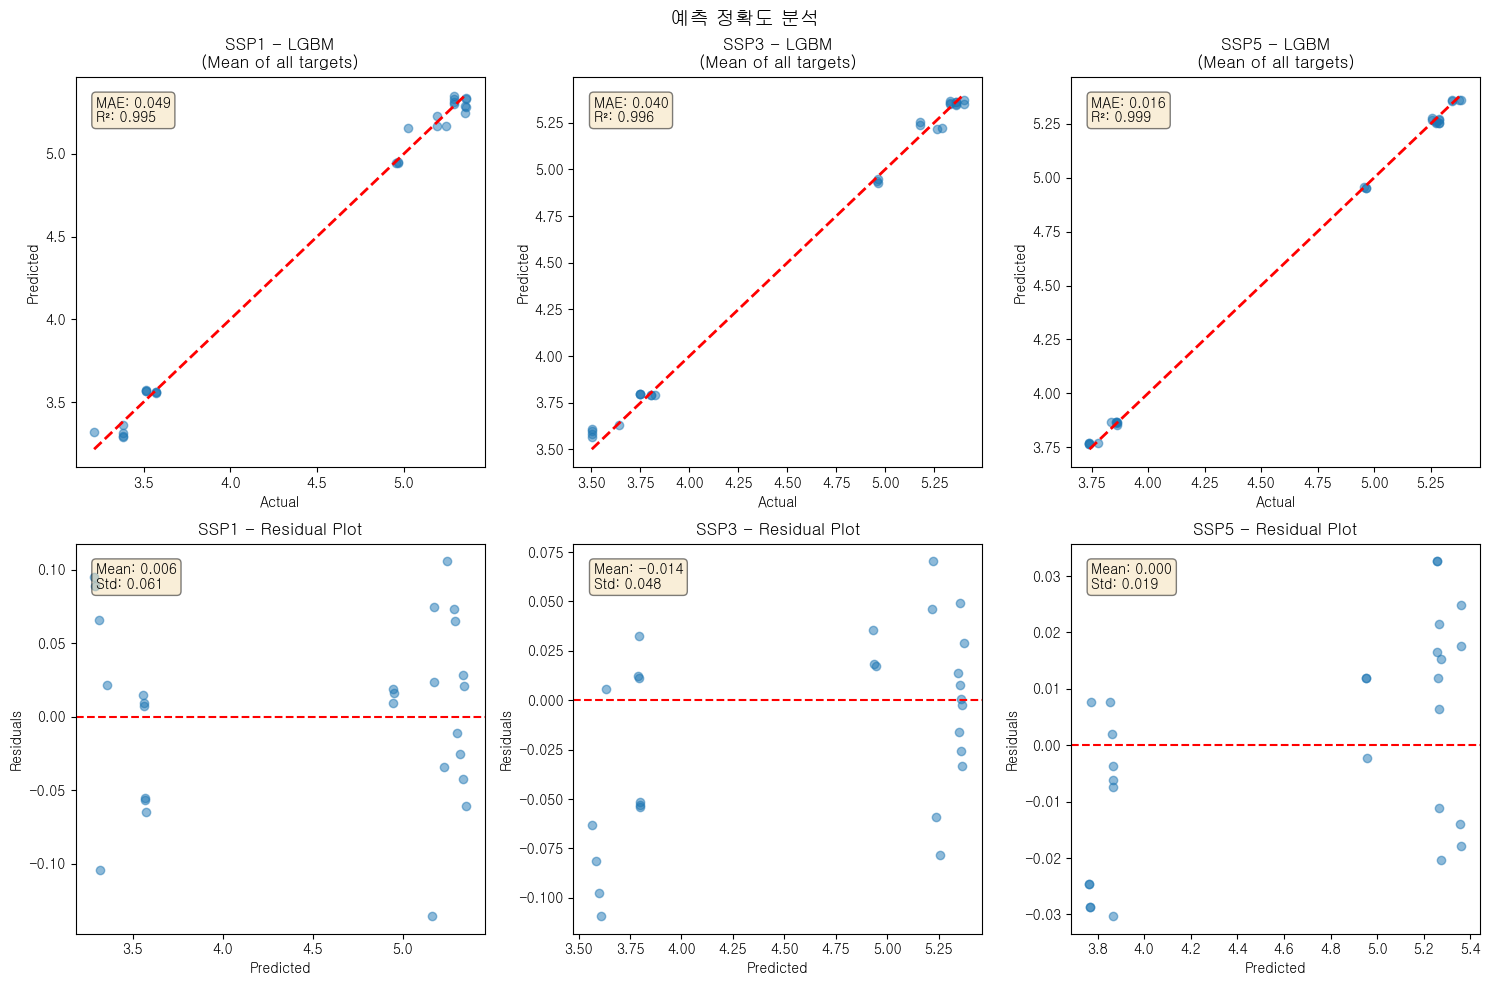

In [77]:
fig2, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, scenario in enumerate(['SSP1', 'SSP3', 'SSP5']):
    # 최고 모델로 예측
    best_name = best_models[scenario]['name']
    model = best_models[scenario]['model']
    scaler = best_models[scenario]['scaler']
    
    # 데이터 준비
    scenario_mask = scenarios == scenario
    X_scenario = X_engineered[scenario_mask]
    y_scenario = y_targets[scenario_mask]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_scenario, y_scenario, test_size=0.2, random_state=42
    )
    
    X_test_scaled = scaler.transform(X_test)
    y_pred = model.predict(X_test_scaled)
    
    # 예측 vs 실제 (모든 타겟 평균)
    ax = axes[0, idx]
    y_test_mean = y_test.mean(axis=1)
    y_pred_mean = y_pred.mean(axis=1)
    
    ax.scatter(y_test_mean, y_pred_mean, alpha=0.5)
    ax.plot([y_test_mean.min(), y_test_mean.max()], 
           [y_test_mean.min(), y_test_mean.max()], 
           'r--', lw=2)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{scenario} - {best_name}\n(Mean of all targets)')
    
    # 텍스트 추가
    mae = mean_absolute_error(y_test_mean, y_pred_mean)
    r2 = r2_score(y_test_mean, y_pred_mean)
    ax.text(0.05, 0.95, f'MAE: {mae:.3f}\nR²: {r2:.3f}', 
           transform=ax.transAxes, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 잔차 플롯
    ax = axes[1, idx]
    residuals = y_test_mean - y_pred_mean
    ax.scatter(y_pred_mean, residuals, alpha=0.5)
    ax.axhline(y=0, color='r', linestyle='--')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residuals')
    ax.set_title(f'{scenario} - Residual Plot')
    
    # 잔차 통계
    ax.text(0.05, 0.95, f'Mean: {residuals.mean():.3f}\nStd: {residuals.std():.3f}', 
           transform=ax.transAxes, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('예측 정확도 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [79]:
print("\n📊 시나리오별 최고 성능 모델:")
print("-"*50)
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    best = min(scenario_results[scenario].items(), key=lambda x: x[1]['MAE'])
    print(f"\n{scenario} 시나리오:")
    print(f"  모델: {best[0]}")
    print(f"  MAE: {safe_float(best[1]['MAE']):.4f}")
    print(f"  R2: {safe_float(best[1]['R2']):.4f}")
    print(f"  PI: {safe_float(best[1]['PI']):.4f}")
    print(f"  MAPE: {safe_float(best[1]['MAPE']):.2f}%")

print("\n🏆 앙상블 모델 성능 향상:")
print("-"*50)
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    best_individual = min(scenario_results[scenario].items(), key=lambda x: x[1]['MAE'])
    ensemble = ensemble_results[scenario]
    improvement = (best_individual[1]['MAE'] - ensemble['MAE']) / best_individual[1]['MAE'] * 100
    
    print(f"{scenario}: {improvement:+.1f}% 개선 (MAE {best_individual[1]['MAE']:.4f} → {ensemble['MAE']:.4f})")

print("\n🔑 핵심 영향 인자 (Top 3):")
print("-"*50)
for scenario in ['SSP1', 'SSP3', 'SSP5']:
    print(f"\n{scenario}:")
    importance = feature_importance_results[scenario]
    top_indices = np.argsort(importance)[-3:][::-1]
    for rank, idx in enumerate(top_indices, 1):
        print(f"  {rank}. {X_engineered.columns[idx]}: {importance[idx]:.4f}")


📊 시나리오별 최고 성능 모델:
--------------------------------------------------

SSP1 시나리오:
  모델: LGBM
  MAE: 0.0680
  R2: 0.9731
  PI: 0.9955
  MAPE: 1.63%

SSP3 시나리오:
  모델: LGBM
  MAE: 0.0520
  R2: 0.9705
  PI: 0.9984
  MAPE: 1.59%

SSP5 시나리오:
  모델: LGBM
  MAE: 0.0330
  R2: 0.9631
  PI: 0.9992
  MAPE: 1.12%

🏆 앙상블 모델 성능 향상:
--------------------------------------------------
SSP1: -3.3% 개선 (MAE 0.0680 → 0.0703)
SSP3: -8.2% 개선 (MAE 0.0520 → 0.0562)
SSP5: -5.4% 개선 (MAE 0.0330 → 0.0348)

🔑 핵심 영향 인자 (Top 3):
--------------------------------------------------

SSP1:
  1. growth_stage: 0.4884
  2. growth_stage_sq: 0.4224
  3. temp_stress: 0.0116

SSP3:
  1. growth_stage: 0.4664
  2. growth_stage_sq: 0.4435
  3. Dio-RC: 0.0096

SSP5:
  1. growth_stage_sq: 0.3450
  2. growth_stage: 0.2837
  3. Dio-RC: 0.2752
